# Kernel Comparison: Linear, Polynomial, RBF

**Objective:** Perform a systematic comparison of linear, polynomial, and RBF kernels across multiple datasets, generating quantitative metrics and visualizations to guide kernel selection in practice.

**Key Concepts:**
- Quantitative comparison of kernel performance
- Metrics: accuracy, precision, recall, F1-score
- When to use each kernel
- RBF as the "universal" default kernel
- Practical guidelines for kernel selection

**Package:** `rkhs_kernel_methods`

In [35]:
import sys, os
# Ensure src/ is on the path regardless of where Jupyter was launched
for _candidate in (os.path.join(os.getcwd(), 'src'),
                   os.path.join(os.getcwd(), '..', 'src')):
    _p = os.path.abspath(_candidate)
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.insert(0, _p)
        break


In [36]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from rkhs_kernel_methods import (
    make_linearly_separable,
    make_nonlinear_datasets,
    load_all_datasets,
    train_linear_svm,
    train_kernel_svm,
    plot_decision_boundary,
    plot_kernel_comparison,
    evaluate_model,
    compare_kernels,
    generate_comparison_table,
    save_results_csv,
    linear_kernel,
    polynomial_kernel,
    rbf_kernel,
    compute_kernel_gram,
    set_style,
    set_random_seed,
    ensure_dir,
)

set_style()
set_random_seed(42)
print("Package loaded.")

Package loaded.


## 1. Load All Datasets

We use three datasets that test different geometric properties:
- **Linear**: Two well-separated Gaussian blobs (linearly separable)
- **Moons**: Two interleaving crescent shapes (nonlinear, curved)
- **Circles**: Concentric rings (nonlinear, radially symmetric)

In [37]:
datasets = load_all_datasets(n_samples=300, random_state=42)

kernels = ["linear", "poly", "rbf"]
kernel_labels = ["Linear", "Polynomial", "RBF"]

print("Datasets loaded:")
for name, (X, y) in datasets.items():
    print(f"  {name:8s} -> X: {X.shape}, classes: {np.unique(y)}")

Datasets loaded:
  linear   -> X: (300, 2), classes: [-1  1]
  moons    -> X: (300, 2), classes: [-1  1]
  circles  -> X: (300, 2), classes: [-1  1]


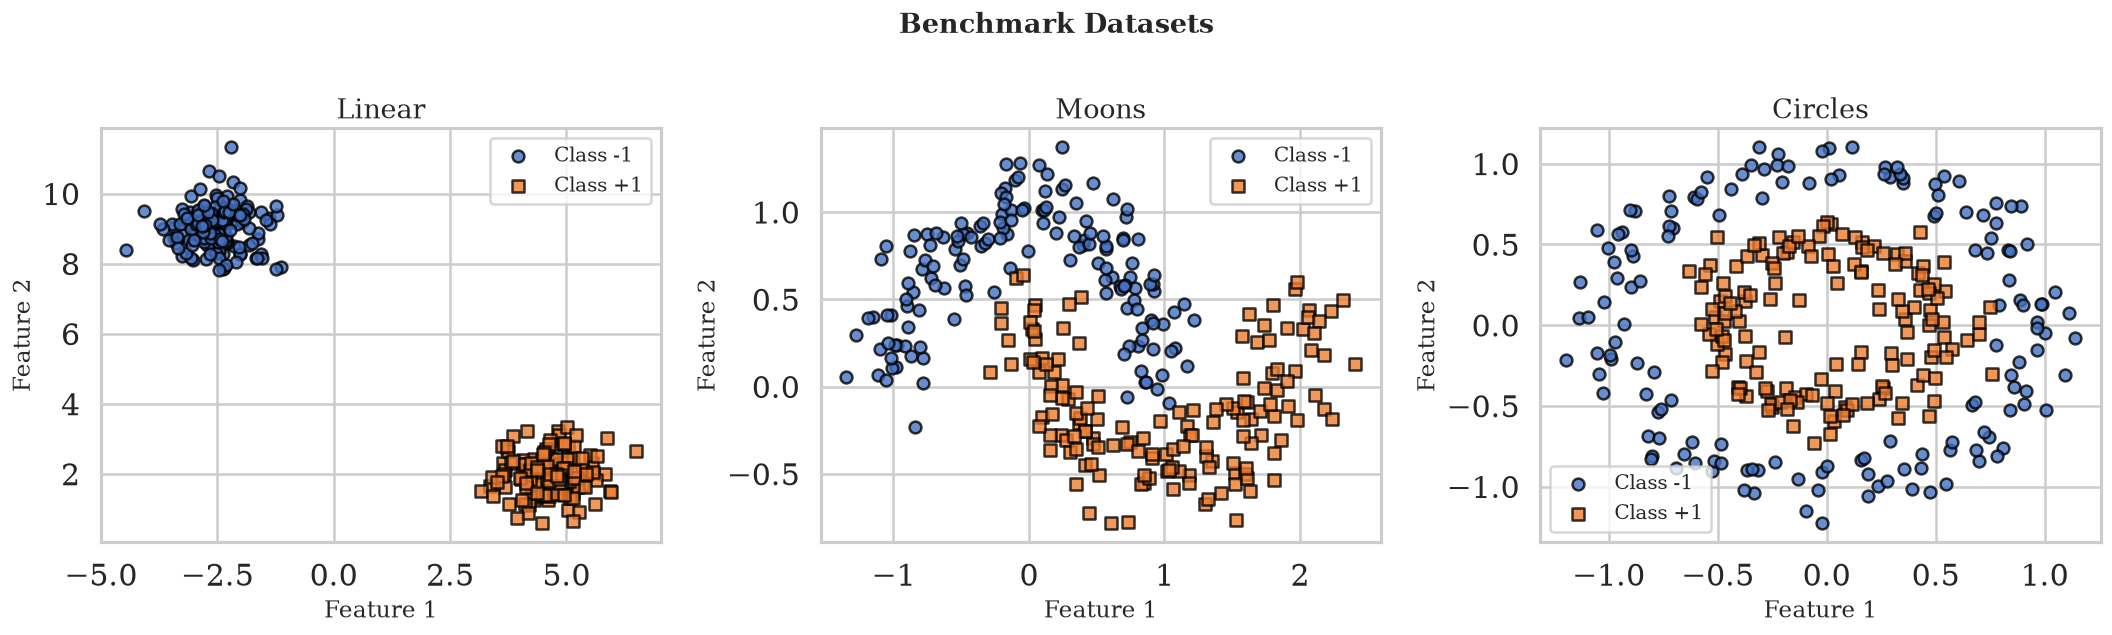

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
from rkhs_kernel_methods import plot_dataset
for ax, (name, (X, y)) in zip(axes, datasets.items()):
    plot_dataset(X, y, title=name.title(), ax=ax)
plt.suptitle("Benchmark Datasets", fontsize=16, fontweight="bold")
plt.tight_layout()


## 2. Systematic Comparison Across Datasets and Kernels

We train each kernel on each dataset and compute accuracy, precision, recall, and F1-score.

In [39]:
comparison_df = generate_comparison_table(
    datasets, kernels, C=1.0, random_state=42
)

print("\n=== Full Comparison Table ===\n")
print(comparison_df.to_string())


=== Full Comparison Table ===

                accuracy  precision    recall        f1
dataset kernel                                         
linear  linear  1.000000   1.000000  1.000000  1.000000
        poly    1.000000   1.000000  1.000000  1.000000
        rbf     1.000000   1.000000  1.000000  1.000000
moons   linear  0.863333   0.860927  0.866667  0.863787
        poly    0.983333   0.980132  0.986667  0.983389
        rbf     0.983333   0.986577  0.980000  0.983278
circles linear  0.550000   0.540107  0.673333  0.599407
        poly    0.996667   1.000000  0.993333  0.996656
        rbf     0.993333   1.000000  0.986667  0.993289


In [40]:
from IPython.display import display
display(comparison_df)


accuracy  precision    recall        f1
dataset kernel                                         
linear  linear  1.000000   1.000000  1.000000  1.000000
        poly    1.000000   1.000000  1.000000  1.000000
        rbf     1.000000   1.000000  1.000000  1.000000
moons   linear  0.863333   0.860927  0.866667  0.863787
        poly    0.983333   0.980132  0.986667  0.983389
        rbf     0.983333   0.986577  0.980000  0.983278
circles linear  0.550000   0.540107  0.673333  0.599407
        poly    0.996667   1.000000  0.993333  0.996656
        rbf     0.993333   1.000000  0.986667  0.993289

## 3. Bar Chart Comparison

A visual comparison of accuracy across datasets and kernels.

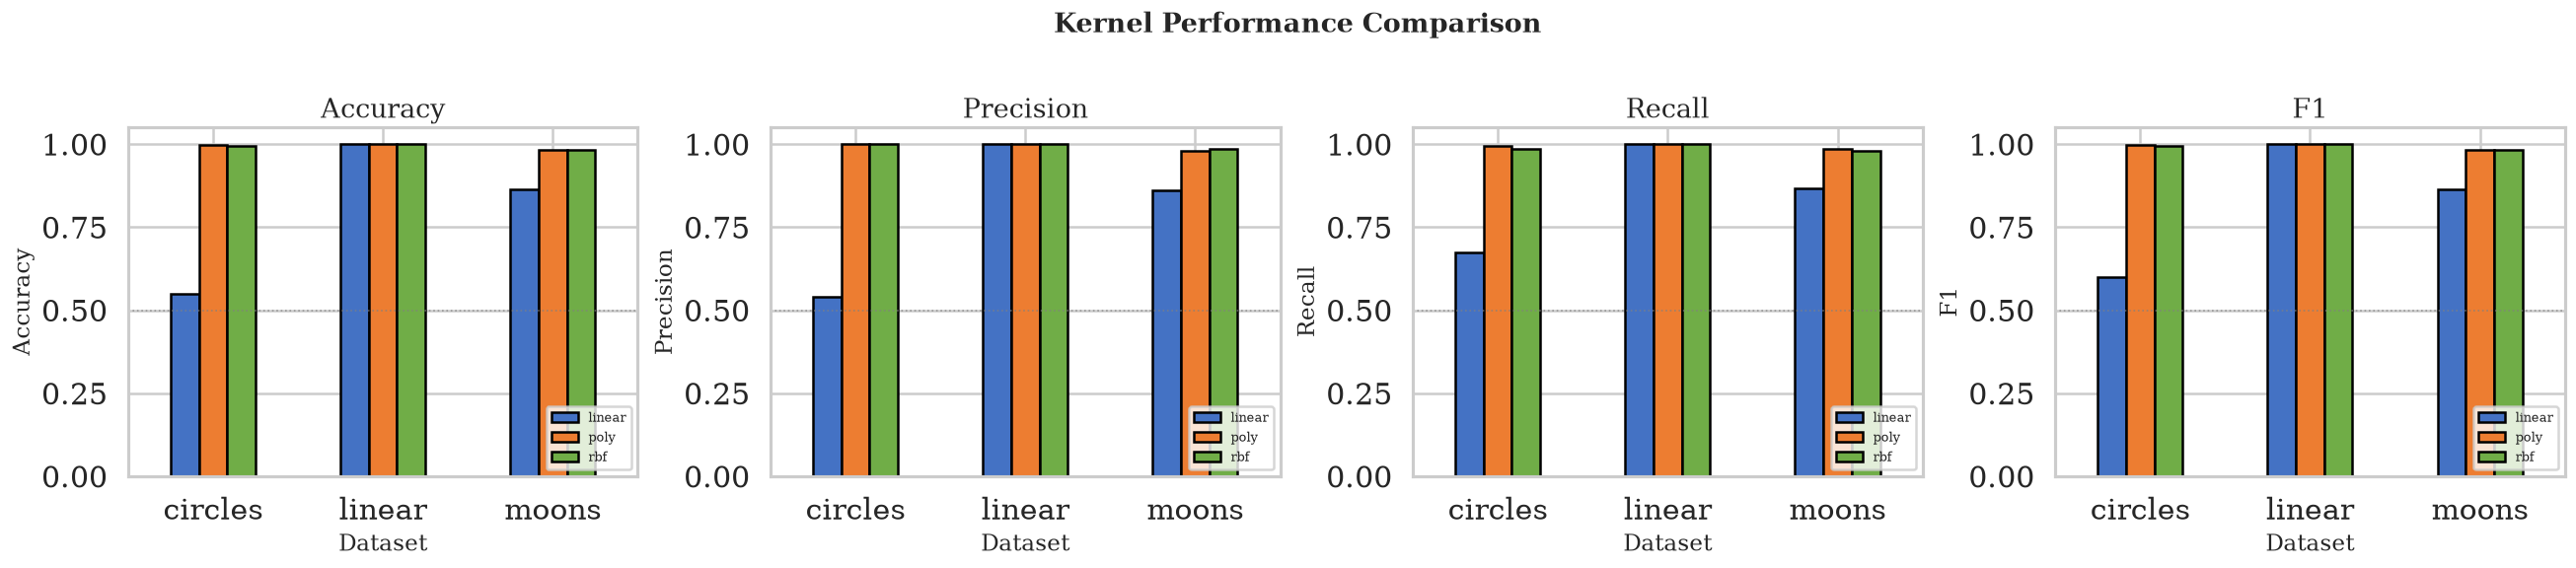

In [41]:
flat_df = comparison_df.reset_index()

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

metrics_list = ["accuracy", "precision", "recall", "f1"]

for i, metric in enumerate(metrics_list):
    ax = axes[i]
    pivot = flat_df.pivot(index="dataset", columns="kernel", values=metric)
    pivot = pivot[kernels]
    pivot.plot(kind="bar", ax=ax, color=["#4472C4", "#ED7D31", "#70AD47"], edgecolor="black")
    ax.set_title(metric.title())
    ax.set_ylabel(metric.title())
    ax.set_ylim(0, 1.05)
    ax.axhline(y=0.50, color="gray", linestyle=":", alpha=0.7, linewidth=1)
    ax.set_xlabel("Dataset")
    ax.legend(loc="lower right", fontsize=8)
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Kernel Performance Comparison", fontsize=16, fontweight="bold")
plt.tight_layout()


**Insights:**
- On the **linear** dataset, all three kernels perform well (it's an easy problem).
- On **moons**, linear SVM fails badly while polynomial and RBF achieve high accuracy.
- On **circles**, only RBF achieves near-perfect performance due to its radial structure.
- RBF is the most **robust** kernel across all datasets.

## 4. Heatmap Visualization

A heatmap provides a compact overview of which kernels work best on which datasets.

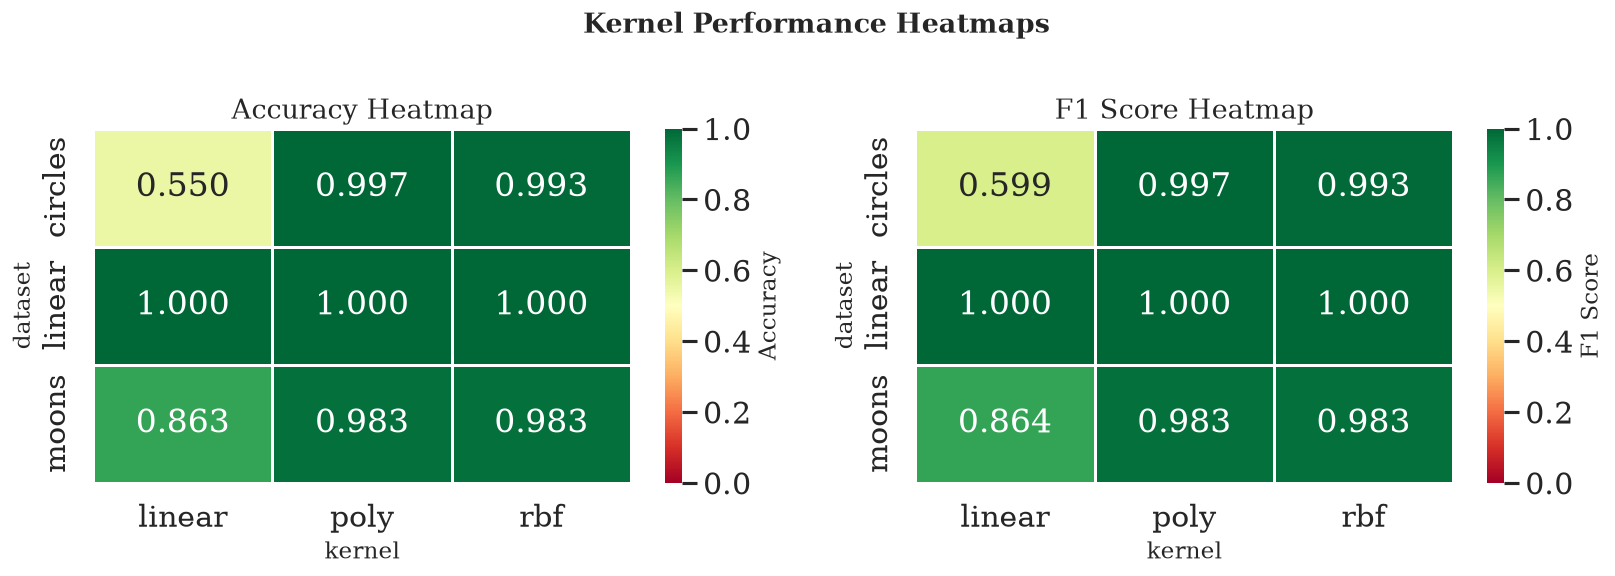

In [42]:
heatmap_data = flat_df.pivot(index="dataset", columns="kernel", values="accuracy")
heatmap_data = heatmap_data[kernels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    heatmap_data, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0.0, vmax=1.0, linewidths=1.5, cbar_kws={"label": "Accuracy"},
    ax=axes[0]
)
axes[0].set_title("Accuracy Heatmap")

f1_data = flat_df.pivot(index="dataset", columns="kernel", values="f1")
f1_data = f1_data[kernels]
sns.heatmap(
    f1_data, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0.0, vmax=1.0, linewidths=1.5, cbar_kws={"label": "F1 Score"},
    ax=axes[1]
)
axes[1].set_title("F1 Score Heatmap")

plt.suptitle("Kernel Performance Heatmaps", fontsize=16, fontweight="bold")
plt.tight_layout()


## 5. Support Vector Analysis

The number of support vectors affects model complexity and inference speed.

In [43]:
sv_data = []
for name, (X, y) in datasets.items():
    n_total = len(X)
    for kernel_name in kernels:
        model = train_kernel_svm(X, y, kernel=kernel_name, C=1.0, random_state=42)
        n_sv = len(model.support_vectors_)
        sv_data.append({
            "Dataset": name.title(),
            "Kernel": kernel_name.title(),
            "Support Vectors": n_sv,
            "SV Ratio (%)": 100 * n_sv / n_total,
        })

sv_df = pd.DataFrame(sv_data)
print("=" * 65)
print("SUPPORT VECTOR ANALYSIS")
print("=" * 65)
print(sv_df.to_string(index=False))

SUPPORT VECTOR ANALYSIS
Dataset Kernel  Support Vectors  SV Ratio (%)
 Linear Linear                2      0.666667
 Linear   Poly                3      1.000000
 Linear    Rbf               29      9.666667
  Moons Linear               95     31.666667
  Moons   Poly               45     15.000000
  Moons    Rbf               57     19.000000
Circles Linear              300    100.000000
Circles   Poly               38     12.666667
Circles    Rbf               65     21.666667


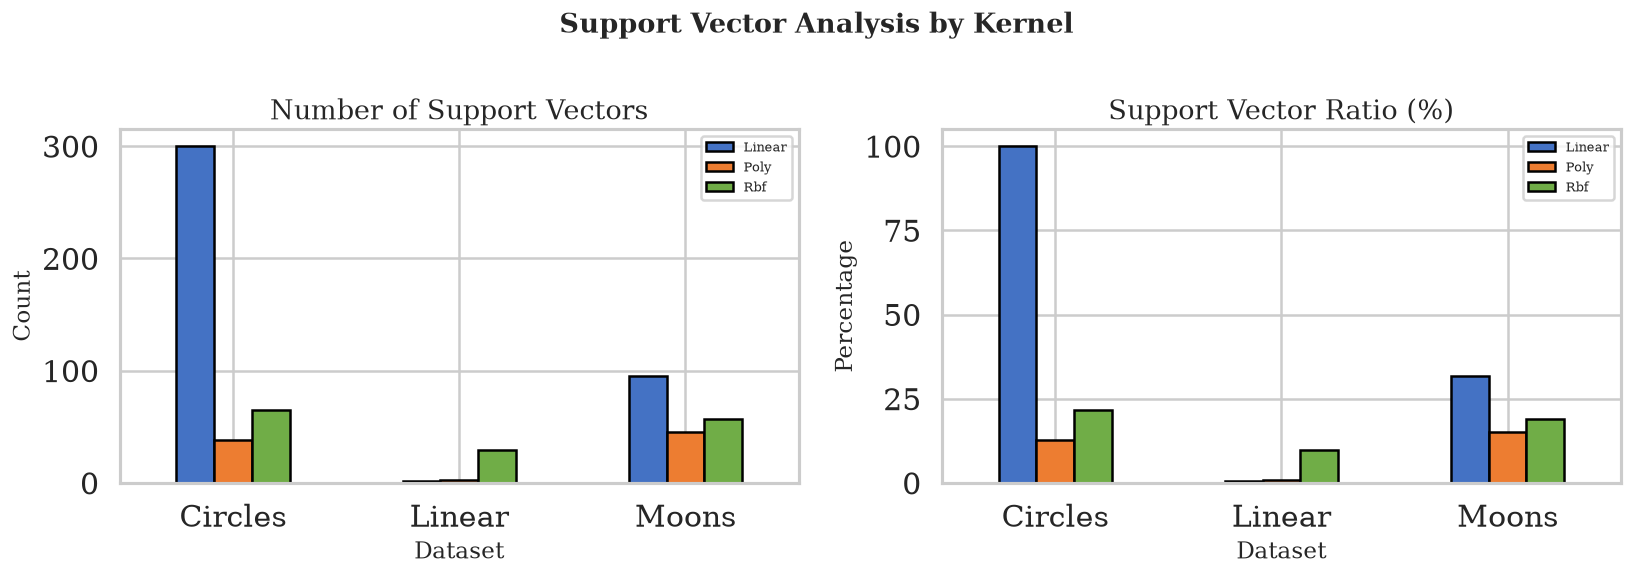

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

pivot_sv = sv_df.pivot(index="Dataset", columns="Kernel", values="Support Vectors")
pivot_sv.plot(kind="bar", ax=ax1, color=["#4472C4", "#ED7D31", "#70AD47"], edgecolor="black")
ax1.set_title("Number of Support Vectors")
ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=0)
ax1.legend(loc="upper right", fontsize=8)

pivot_ratio = sv_df.pivot(index="Dataset", columns="Kernel", values="SV Ratio (%)")
pivot_ratio.plot(kind="bar", ax=ax2, color=["#4472C4", "#ED7D31", "#70AD47"], edgecolor="black")
ax2.set_title("Support Vector Ratio (%)")
ax2.set_ylabel("Percentage")
ax2.tick_params(axis="x", rotation=0)
ax2.legend(loc="upper right", fontsize=8)

plt.suptitle("Support Vector Analysis by Kernel", fontsize=16, fontweight="bold")
plt.tight_layout()


**Observation:** RBF typically uses more support vectors for complex boundaries (circles, moons), which is expected since it needs more basis functions to trace the curved decision boundary. On the linear dataset, all kernels use roughly the same number of SVs.

## 6. Visualizing Decision Boundaries on All Datasets

A grid view showing each kernel's decision boundary on each dataset.

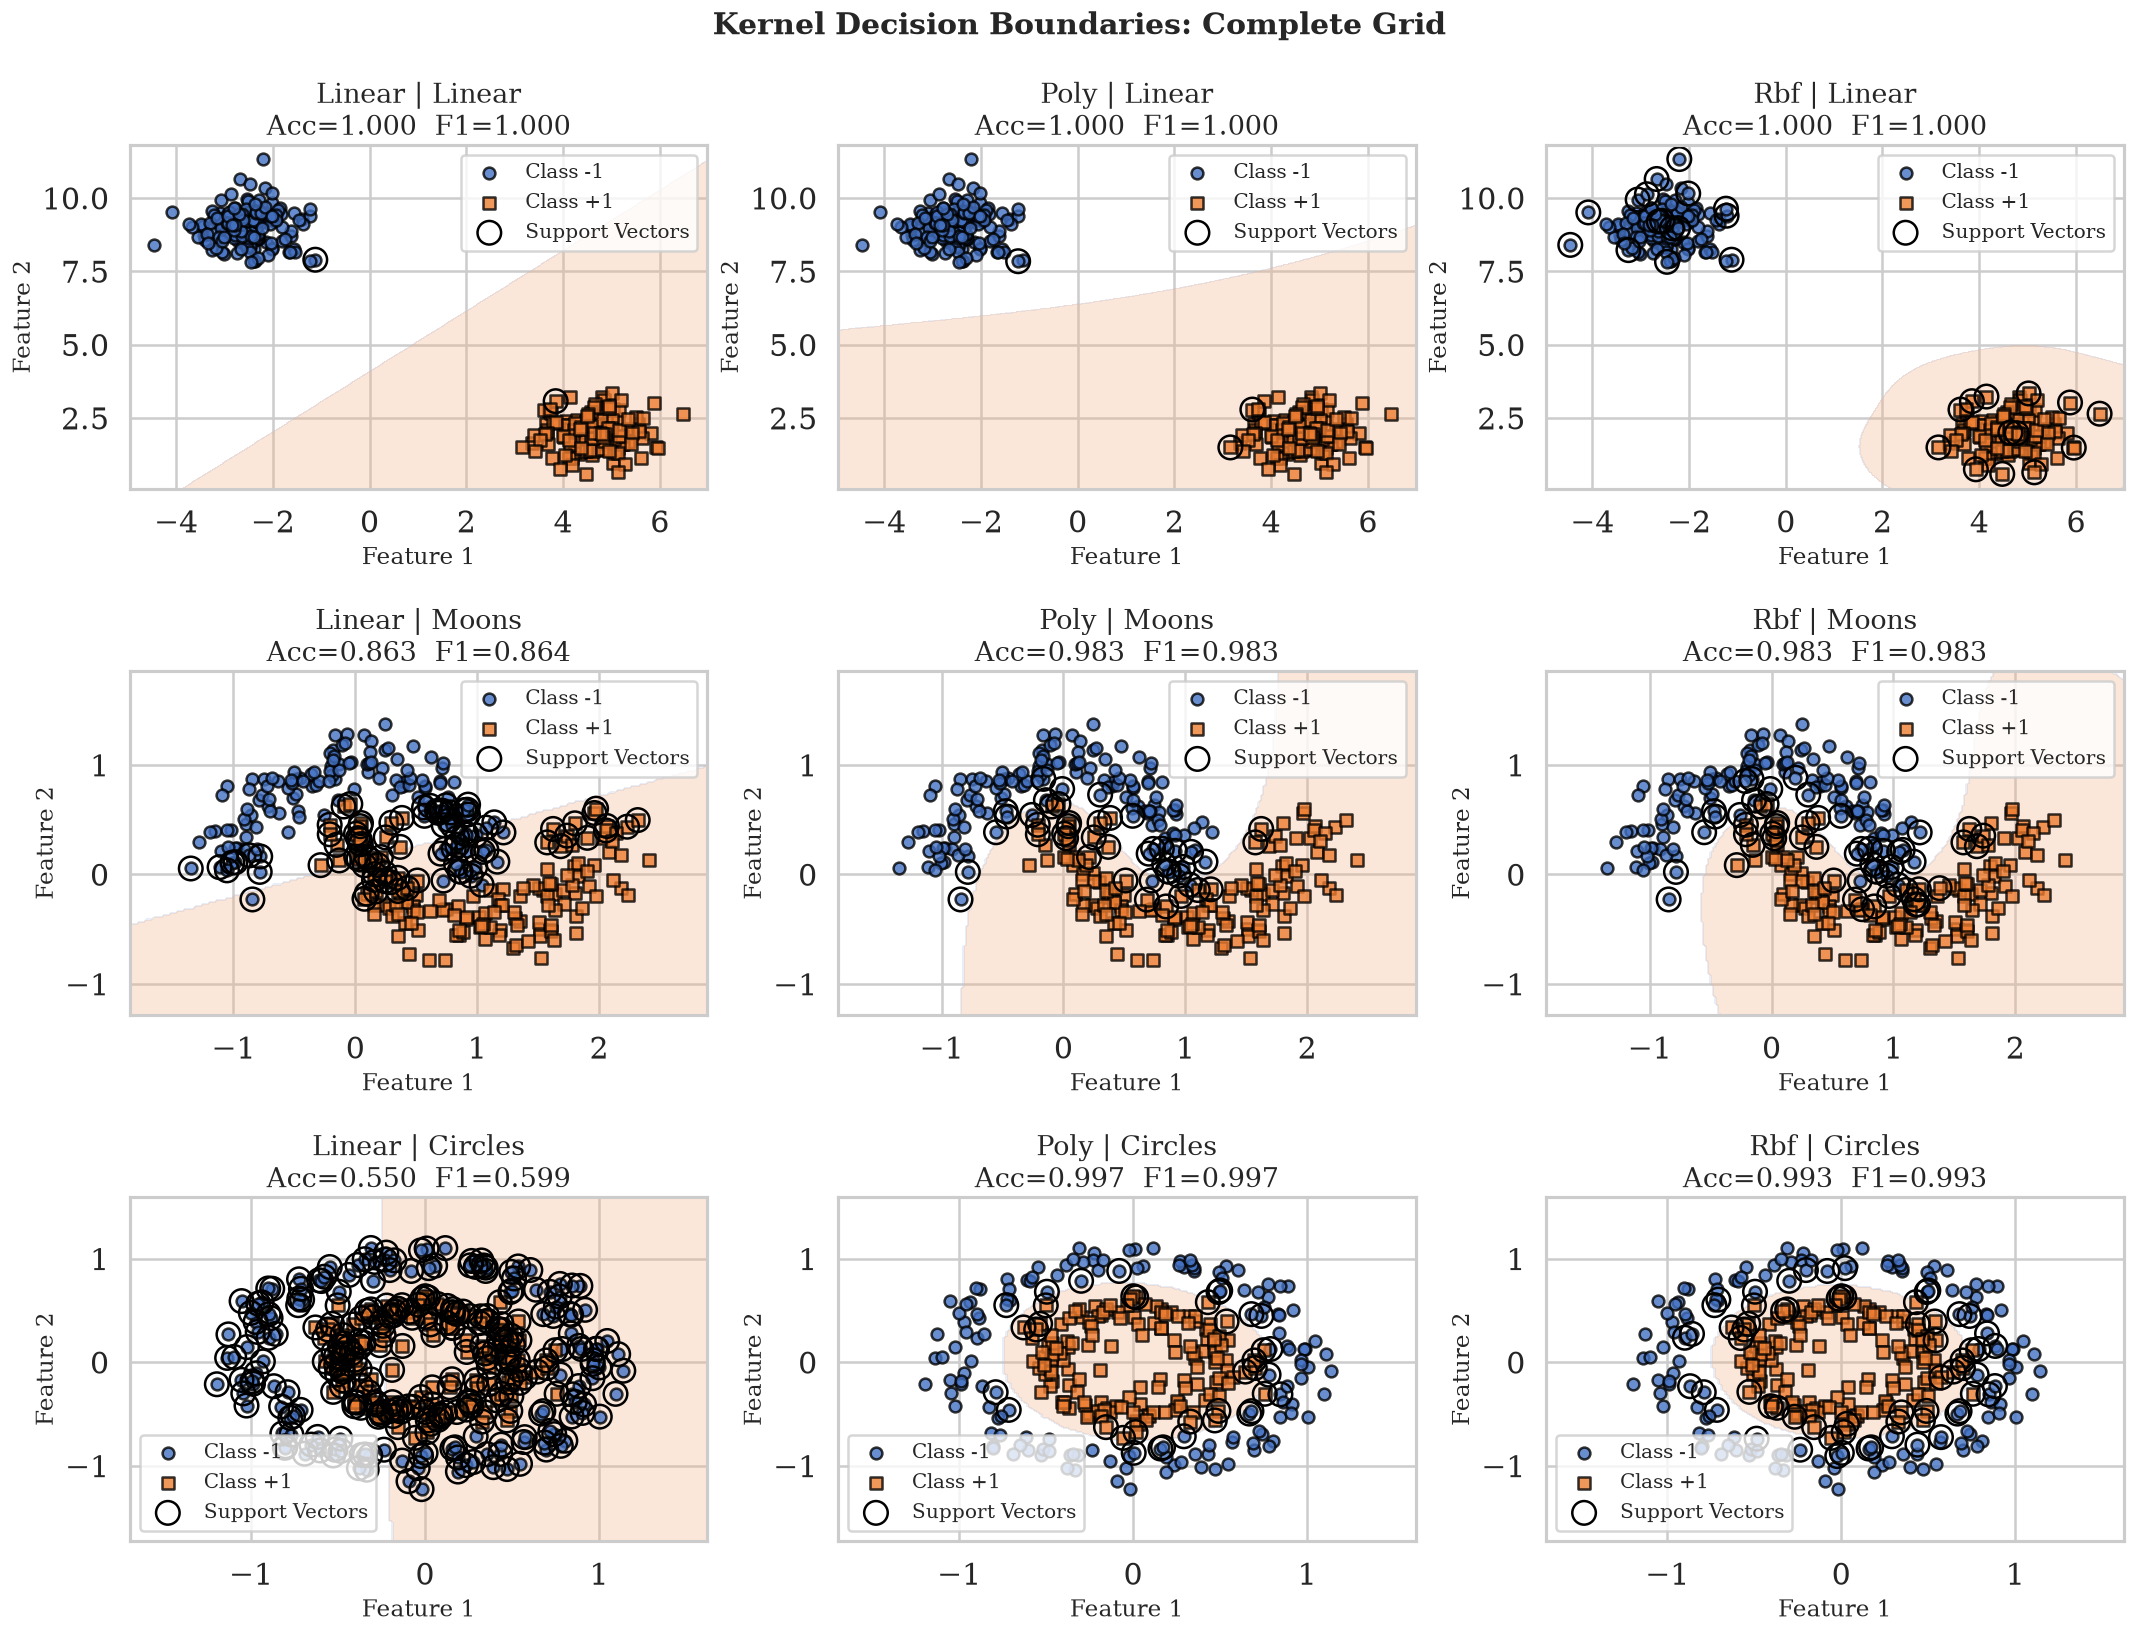

In [45]:
fig, axes = plt.subplots(len(datasets), len(kernels), figsize=(18, 14))

for i, (name, (X, y)) in enumerate(datasets.items()):
    for j, kernel_name in enumerate(kernels):
        ax = axes[i, j]
        model = train_kernel_svm(X, y, kernel=kernel_name, C=1.0, random_state=42)
        metrics = evaluate_model(model, X, y)
        plot_decision_boundary(
            model, X, y,
            title=f"{kernel_name.title()} | {name.title()}\nAcc={metrics['accuracy']:.3f}  F1={metrics['f1']:.3f}",
            highlight_sv=True, ax=ax
        )

plt.suptitle("Kernel Decision Boundaries: Complete Grid", fontsize=18, fontweight="bold")
plt.tight_layout()


## 7. When to Use Each Kernel

### Kernel Selection Guide

| Kernel | Best For | Limitations | Parameters |
|--------|----------|------------|------------|
| **Linear** | High-dimensional data (text), linearly separable problems | Cannot learn nonlinear boundaries | $C$ |
| **Polynomial** | Problems with polynomial structure, moderate nonlinearity | Sensitive to degree choice, can overfit | $C$, $d$, $\gamma$, $r$ |
| **RBF** | General-purpose, most nonlinear problems | Can overfit with small $\gamma$, more SVs | $C$, $\gamma$ |

### Practical Heuristics

1. **Start with Linear**: If the data is high-dimensional (e.g., text TF-IDF with $d > 10{,}000$), start with a linear SVM. It's fast and often sufficient.

2. **Default to RBF**: For most low-to-medium dimensional problems ($d < 1000$), the RBF kernel is the best default choice. It's flexible and has only two hyperparameters ($C$, $\gamma$).

3. **Try Polynomial if interpretability matters**: If you need an interpretable degree of nonlinearity (e.g., quadratic interactions), the polynomial kernel is useful.

4. **Tune $\gamma$ for RBF**:
   - Small $\gamma$: Smooth, simple boundaries (high bias)
   - Large $\gamma$: Complex, wiggly boundaries (high variance)
   - Rule of thumb: $\gamma = 1 / (d \cdot \text{Var}(X))$

5. **Use cross-validation**: Always tune $C$ and $\gamma$ via cross-validation (e.g., grid search with 5-fold CV).

## 8. Gamma Sensitivity for RBF Kernel

The $\gamma$ parameter controls the influence radius of each support vector. Let's see its effect.

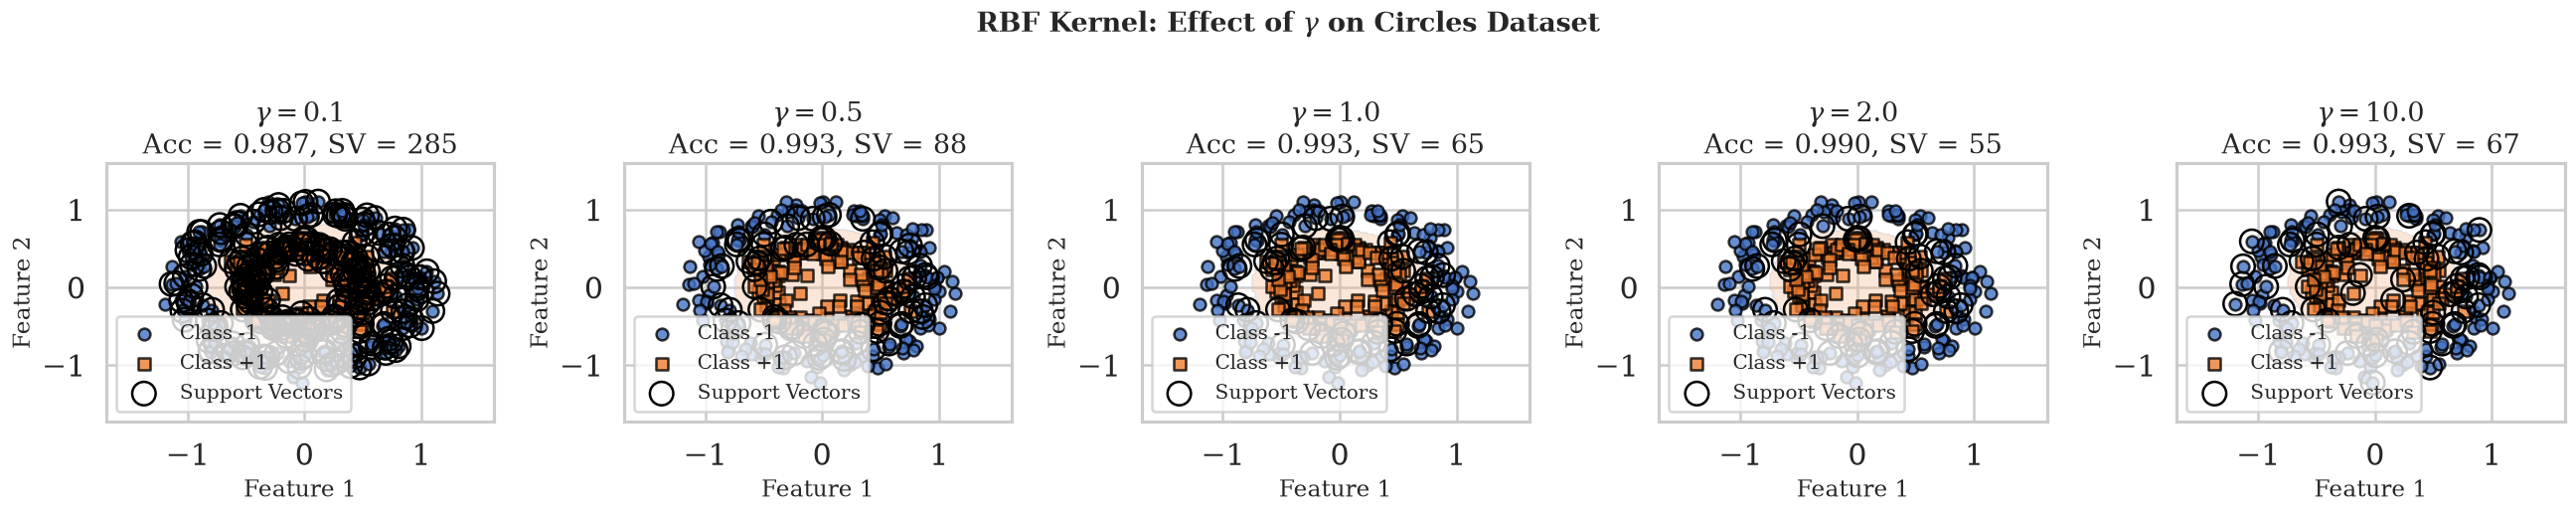

In [46]:
X_c, y_c = datasets["circles"]
gamma_values = [0.1, 0.5, 1.0, 2.0, 10.0]

fig, axes = plt.subplots(1, len(gamma_values), figsize=(22, 4.5))

for ax, gamma in zip(axes, gamma_values):
    model = train_kernel_svm(X_c, y_c, kernel="rbf", C=1.0, gamma=gamma, random_state=42)
    acc = evaluate_model(model, X_c, y_c)["accuracy"]
    n_sv = len(model.support_vectors_)
    plot_decision_boundary(
        model, X_c, y_c,
        title=f"$\\gamma = {gamma}$\nAcc = {acc:.3f}, SV = {n_sv}",
        highlight_sv=True, ax=ax
    )

plt.suptitle("RBF Kernel: Effect of $\\gamma$ on Circles Dataset", fontsize=16, fontweight="bold")
plt.tight_layout()


**Observation:**
- $\gamma = 0.1$: Too smooth, boundary is almost linear (underfitting).
- $\gamma = 1.0$: Good balance, captures the circular structure.
- $\gamma = 10.0$: Too complex, boundary becomes jagged (overfitting), many more support vectors.

## 9. Running Time Comparison

Training time varies by kernel complexity and dataset size.

In [47]:
from rkhs_kernel_methods import Timer
import time

timing_data = []

for name, (X, y) in datasets.items():
    for kernel_name in kernels:
        start = time.perf_counter()
        _ = train_kernel_svm(X, y, kernel=kernel_name, C=1.0, random_state=42)
        elapsed = time.perf_counter() - start
        timing_data.append({
            "Dataset": name.title(),
            "Kernel": kernel_name.title(),
            "Time (ms)": elapsed * 1000,
        })

timing_df = pd.DataFrame(timing_data)
print("\n=== Training Time Comparison ===\n")
print(timing_df.to_string(index=False))


=== Training Time Comparison ===

Dataset Kernel  Time (ms)
 Linear Linear     3.7438
 Linear   Poly     2.4195
 Linear    Rbf     3.9714
  Moons Linear     4.8722
  Moons   Poly     3.3731
  Moons    Rbf     4.0059
Circles Linear     4.9349
Circles   Poly     3.1014
Circles    Rbf     3.3332


## 10. Saving Results

Export the comparison table to CSV for reporting.

In [48]:
output_dir = ensure_dir("../results")
save_results_csv(comparison_df, "../results/kernel_comparison.csv")
print(f"Results saved to: {output_dir}/kernel_comparison.csv")

print("\n" + "=" * 65)
print("COMPARISON SUMMARY")
print("=" * 65)
print(comparison_df.to_string())

Results saved to: ../results/kernel_comparison.csv

COMPARISON SUMMARY
                accuracy  precision    recall        f1
dataset kernel                                         
linear  linear  1.000000   1.000000  1.000000  1.000000
        poly    1.000000   1.000000  1.000000  1.000000
        rbf     1.000000   1.000000  1.000000  1.000000
moons   linear  0.863333   0.860927  0.866667  0.863787
        poly    0.983333   0.980132  0.986667  0.983389
        rbf     0.983333   0.986577  0.980000  0.983278
circles linear  0.550000   0.540107  0.673333  0.599407
        poly    0.996667   1.000000  0.993333  0.996656
        rbf     0.993333   1.000000  0.986667  0.993289


## Final Summary: Practical Kernel Selection

1. **Linear kernel** is the baseline. Use it for:
   - High-dimensional sparse data (text, genomics)
   - Linearly separable problems
   - When interpretability of feature weights matters
   - When training speed is critical

2. **RBF kernel** is the universal default. Use it for:
   - Most real-world problems with moderate dimensionality
   - When you don't have strong prior knowledge about data structure
   - Nonlinear problems where flexibility is needed
   - Has only 2 hyperparameters (easy to tune)

3. **Polynomial kernel** is for specific cases:
   - When you expect polynomial interactions between features
   - When interpretability of the degree matters
   - Natural language processing (sometimes)
   - Disadvantage: more hyperparameters to tune ($d$, $\gamma$, $r$)

### The Golden Rule

**Always try linear first, then RBF.** If RBF overfits, increase $C$ or decrease $\gamma$. If RBF underfits, decrease $C$ or increase $\gamma$. Use cross-validation to tune.